In [2]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

from astropy.coordinates import Galactic, ICRS, SkyCoord, GalacticLSR
from astropy import units as u
from modules.vr_opt import VrOpt
from astropy.table import Table
from pyia import GaiaData

import nbimporter
import visualisations
import consensus_clusterings_luiza as consensus_clusterings

#sys.path.append('/Users/lui/Documents/3_semestr/Project/code/local-clustering/SemiMetricClustering')
#from SemiMetricDensity import SemiMetricDensity
from SemiMetricClustering.SemiMetricDensity import SemiMetricDensity

import square_grid
import shell_grid
from TreeSigMA import TreeSigMAWithHierarchy  
import coord_transformation
import plotting_ftcs_tree
import tree_related_ftcs

In [3]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

In [4]:
#load data set 
tbl = Table.read('50pc_gaiaDR3_parallax_over_error5_sigmax.csv') #150pc_DR3_rv2_parallax_over5_sigmamax_excessnoise, LocalBox_DR3_parallax_over_error10_sigmamax, 50pc_gaiaDR3_parallax_over_error5_sigmax, 100pc_gaiaDR3_parallax_over_error5_sigmamax.csv
g=GaiaData(tbl)

In [5]:
df = g.data.to_pandas()
c, gal, pos_hel, vel_hel, gal_lsr, vel_lsr =coord_transformation.coord_transformation_single(g['ra'].value,g['dec'].value ,(1/g['parallax'].value)*1000,g['pmra'].value,g['pmdec'].value,g['radial_velocity'].value)

In [6]:
df['x'] = pos_hel[0]
df['y'] = pos_hel[1]
df['z'] = pos_hel[2]
df['vx'] = vel_hel[0]
df['vy'] = vel_hel[1]
df['vz'] = vel_hel[2]

df['dist'] = (1/df.parallax)*1000
df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74
#df.to_csv("50pcGaia.csv", index=False)

In [7]:
# Combine with df from pilot study
df_pilot = pd.read_csv('clusters_TucHor_region_pilot.csv')

#Add labels column for certain clusters dict = {1: 'beta Pic', 2: 'Carina',   3: '?',   4: r'$\chi$ For',   5: 'Tuc-Hor',   6: '?',   7: 'Columba'}
df = df.merge(df_pilot[['source_id','labels']], on='source_id', how='left')
# Fill NaN values in 'labels' with 0
df['labels'] = df['labels'].fillna(0).astype(int) #all others get labels 0
labels = df['labels']
print(np.unique(labels))

[0 1 3 5 7]


In [8]:
df

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,...,x,y,z,vx,vy,vz,dist,vt_ra,vt_dec,labels
0,1636148068921376768,Gaia DR3 5937154643067504512,5937154643067504512,1007516695,2016.0,250.637694,0.014857,-51.835705,0.011336,25.893203,...,34.790634,-16.576256,-2.521384,NaN,NaN,NaN,38.620174,-10701.743648,-78826.233926,0
1,1636148068921376768,Gaia DR3 2266317803873109504,2266317803873109504,1152786691,2016.0,280.009155,0.085880,72.682568,0.090319,52.779684,...,-3.954308,16.466184,8.497357,NaN,NaN,NaN,18.946684,-4142.744388,16307.172560,0
2,1636148068921376768,Gaia DR3 2270836070814554752,2270836070814554752,169581691,2016.0,319.017378,0.014472,69.901400,0.014399,27.037899,...,-10.051157,34.393282,9.163823,-18.388251,-60.257577,-12.829609,36.985122,22711.341440,26043.040345,0
3,1636148068921376768,Gaia DR3 2268329119880159232,2268329119880159232,1496160079,2016.0,286.476013,0.023483,75.429909,0.022224,20.051537,...,-13.040758,43.164836,21.304954,-21.008045,20.442763,9.888236,49.871489,4633.381849,13569.759873,0
4,1636148068921376768,Gaia DR3 2268372099615724288,2268372099615724288,646522273,2016.0,285.636636,0.013350,75.418511,0.012652,23.857068,...,-10.907429,36.228068,18.042483,-2.547135,-1.332593,-45.187717,41.916299,40425.236019,-4251.957646,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37871,1636148068921376768,Gaia DR3 6029992663310612096,6029992663310612096,1354746818,2016.0,256.116435,0.022222,-28.583872,0.011692,54.725979,...,18.046718,-1.503843,2.439620,15.335727,-15.676930,-17.630386,18.272857,7215.704978,-23265.553814,0
37872,1636148068921376768,Gaia DR3 1798246358080104448,1798246358080104448,845495564,2016.0,323.092617,0.039232,24.561419,0.030282,48.734047,...,4.843332,18.730242,-6.838970,-11.930070,-1.358440,-17.424169,20.519535,20641.860927,-4304.817353,0
37873,1636148068921376768,Gaia DR3 1798246358081360256,1798246358081360256,437180271,2016.0,323.093029,0.033990,24.561629,0.025776,48.594689,...,4.857075,18.783978,-6.858625,-15.693404,-1.311132,-15.876488,20.578381,22339.701329,-866.495757,0
37874,1636148068921376768,Gaia DR3 6029956340657655424,6029956340657655424,508106269,2016.0,256.662889,0.019832,-28.618132,0.012412,23.650881,...,41.812652,-3.293073,5.348067,-24.271973,-17.914320,2.711918,42.281722,-16209.613196,-12604.183803,0


# Apply TreeSigMA to the whole data set

In [12]:
cluster_features=['x', 'y', 'z']
sigma_kwargs = dict(
        nb_resampling=0,
        max_knn_density=15,#int(np.max(knn_list)+1),
        beta=0.9,
        knn_initcluster_graph=45
    )

# Initialize TreeSigMA
tree_sigma = TreeSigMAWithHierarchy(
    data=df,
    cluster_features=cluster_features,
    knn=10,
    **sigma_kwargs
)

#av50 = [0.00011759,0.00050633,0.0008423,0.00130791,0.00190034,0.00294194,0.00412394,0.0046711,0.00495381,0.00532657,0.00566084,0.00714382,0.00759324,0.0076105,0.00764769,0.00862633,0.00873787,0.00887323,0.01104446,0.01408949,0.01748479,0.01913698,0.02185153,0.02346555,0.02934552,0.02970398,0.03175771,0.03205923,0.03290044,0.03596257,0.03878904,0.0403022,0.04174758,0.04369339,0.04743234,0.0488672,0.0491467,0.05075885,0.05222811,0.05257019,0.05602123,0.06581673,0.06617887,0.06780076,0.06806599,0.06948079,0.07064814,0.07114901,0.08351659,0.08766705,0.08886438,0.08943045,0.08951837,0.08996467,0.09013248 ]
print("Running TreeSigMA clustering...")
alpha_values = tree_sigma.run()#alpha_values = av50
print("Clustering completed. Alpha values:", alpha_values)
print("Used alpha values:", tree_sigma.alpha_values)


# Build hierarchy 
print("\nBuilding hierarchy...")
tree_sigma.build_hierarchy()
print("Hierarchy built.")


node_id = list(tree_sigma.hierarchy.nodes.keys())[0]  # Pick the desired node ID
node = tree_sigma.hierarchy.nodes[node_id]


# Example: Analyzing the leaves
leaves = [node for node in tree_sigma.hierarchy.traverse_top_down() if node.is_leaf()]

Performing gradient ascend using a 10-NN density estimation.
Running TreeSigMA clustering...
Trying to fix hierarchy: need 19 clusters...
Trying alpha=0.003672538139112669
Got  19  clusters
Trying alpha=0.0037185020144273606
Got  19  clusters
Trying alpha=0.0037644658897420524
Got  19  clusters
Trying alpha=0.0038104297650567442
Got  19  clusters
Trying alpha=0.003856393640371436
Got  19  clusters
Trying alpha=0.003902357515686128
Got  18  clusters
Trying alpha=0.00394832139100082
Got  18  clusters
Trying alpha=0.0039942852663155115
Got  18  clusters
Trying to skip 1 alpha value at 0.003891806549487564
Trying alpha=0.004040249141630203
Got  18  clusters
Trying to skip 2 alpha values at 0.003891806549487564
Trying alpha=0.004341107556695312
Got  19  clusters
Number of clusters did not increase by 1 at alpha=18 and alpha=0.003891806549487564.
Returning the hierarchy up to this point.
Clustering completed. Alpha values: [9.75797672053691e-07, 2.0661219915230067e-05, 6.237391704638773e-05,

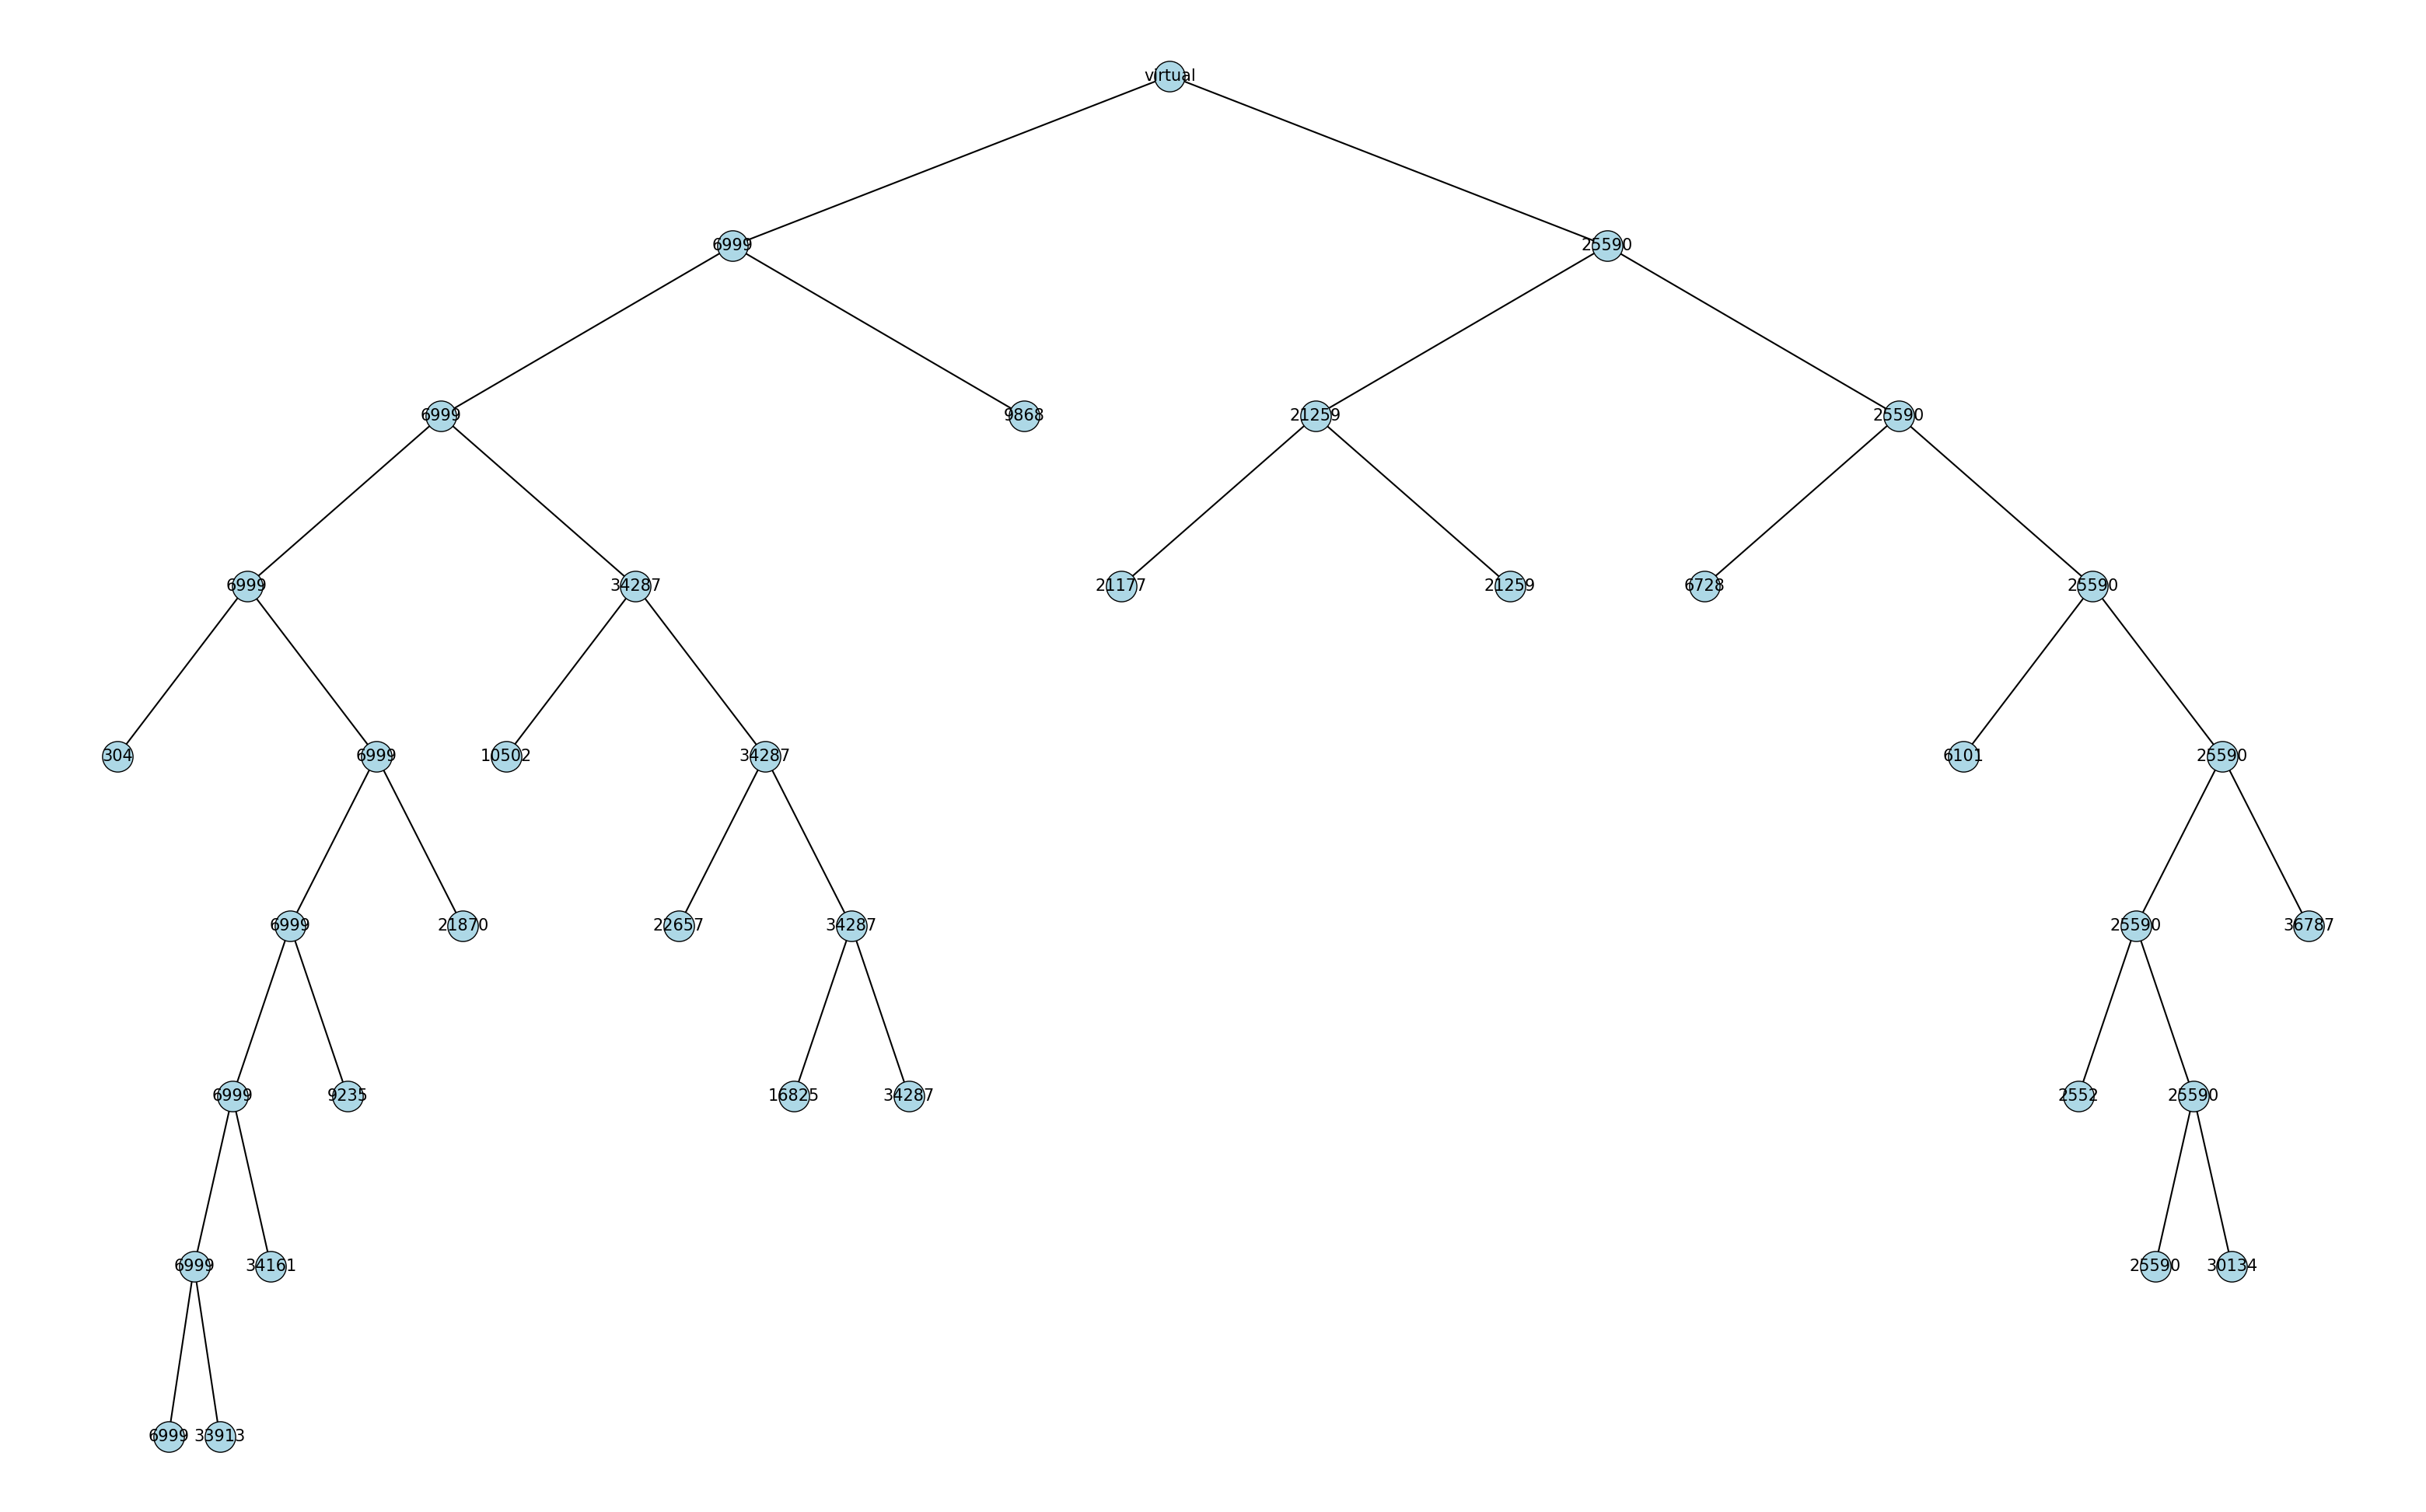

In [18]:
plotting_ftcs_tree.plot_tree(tree_sigma.hierarchy.root, tree_sigma)

In [19]:
#postprocessing the tree - if cluster got less than star_threshold stars, remove children from tree (if they are leaves)
X = df[['x', 'y', 'z']].values
pruned_tree = tree_sigma.prune_tree(star_threshold=20, X=X, min_skew = 0.8)

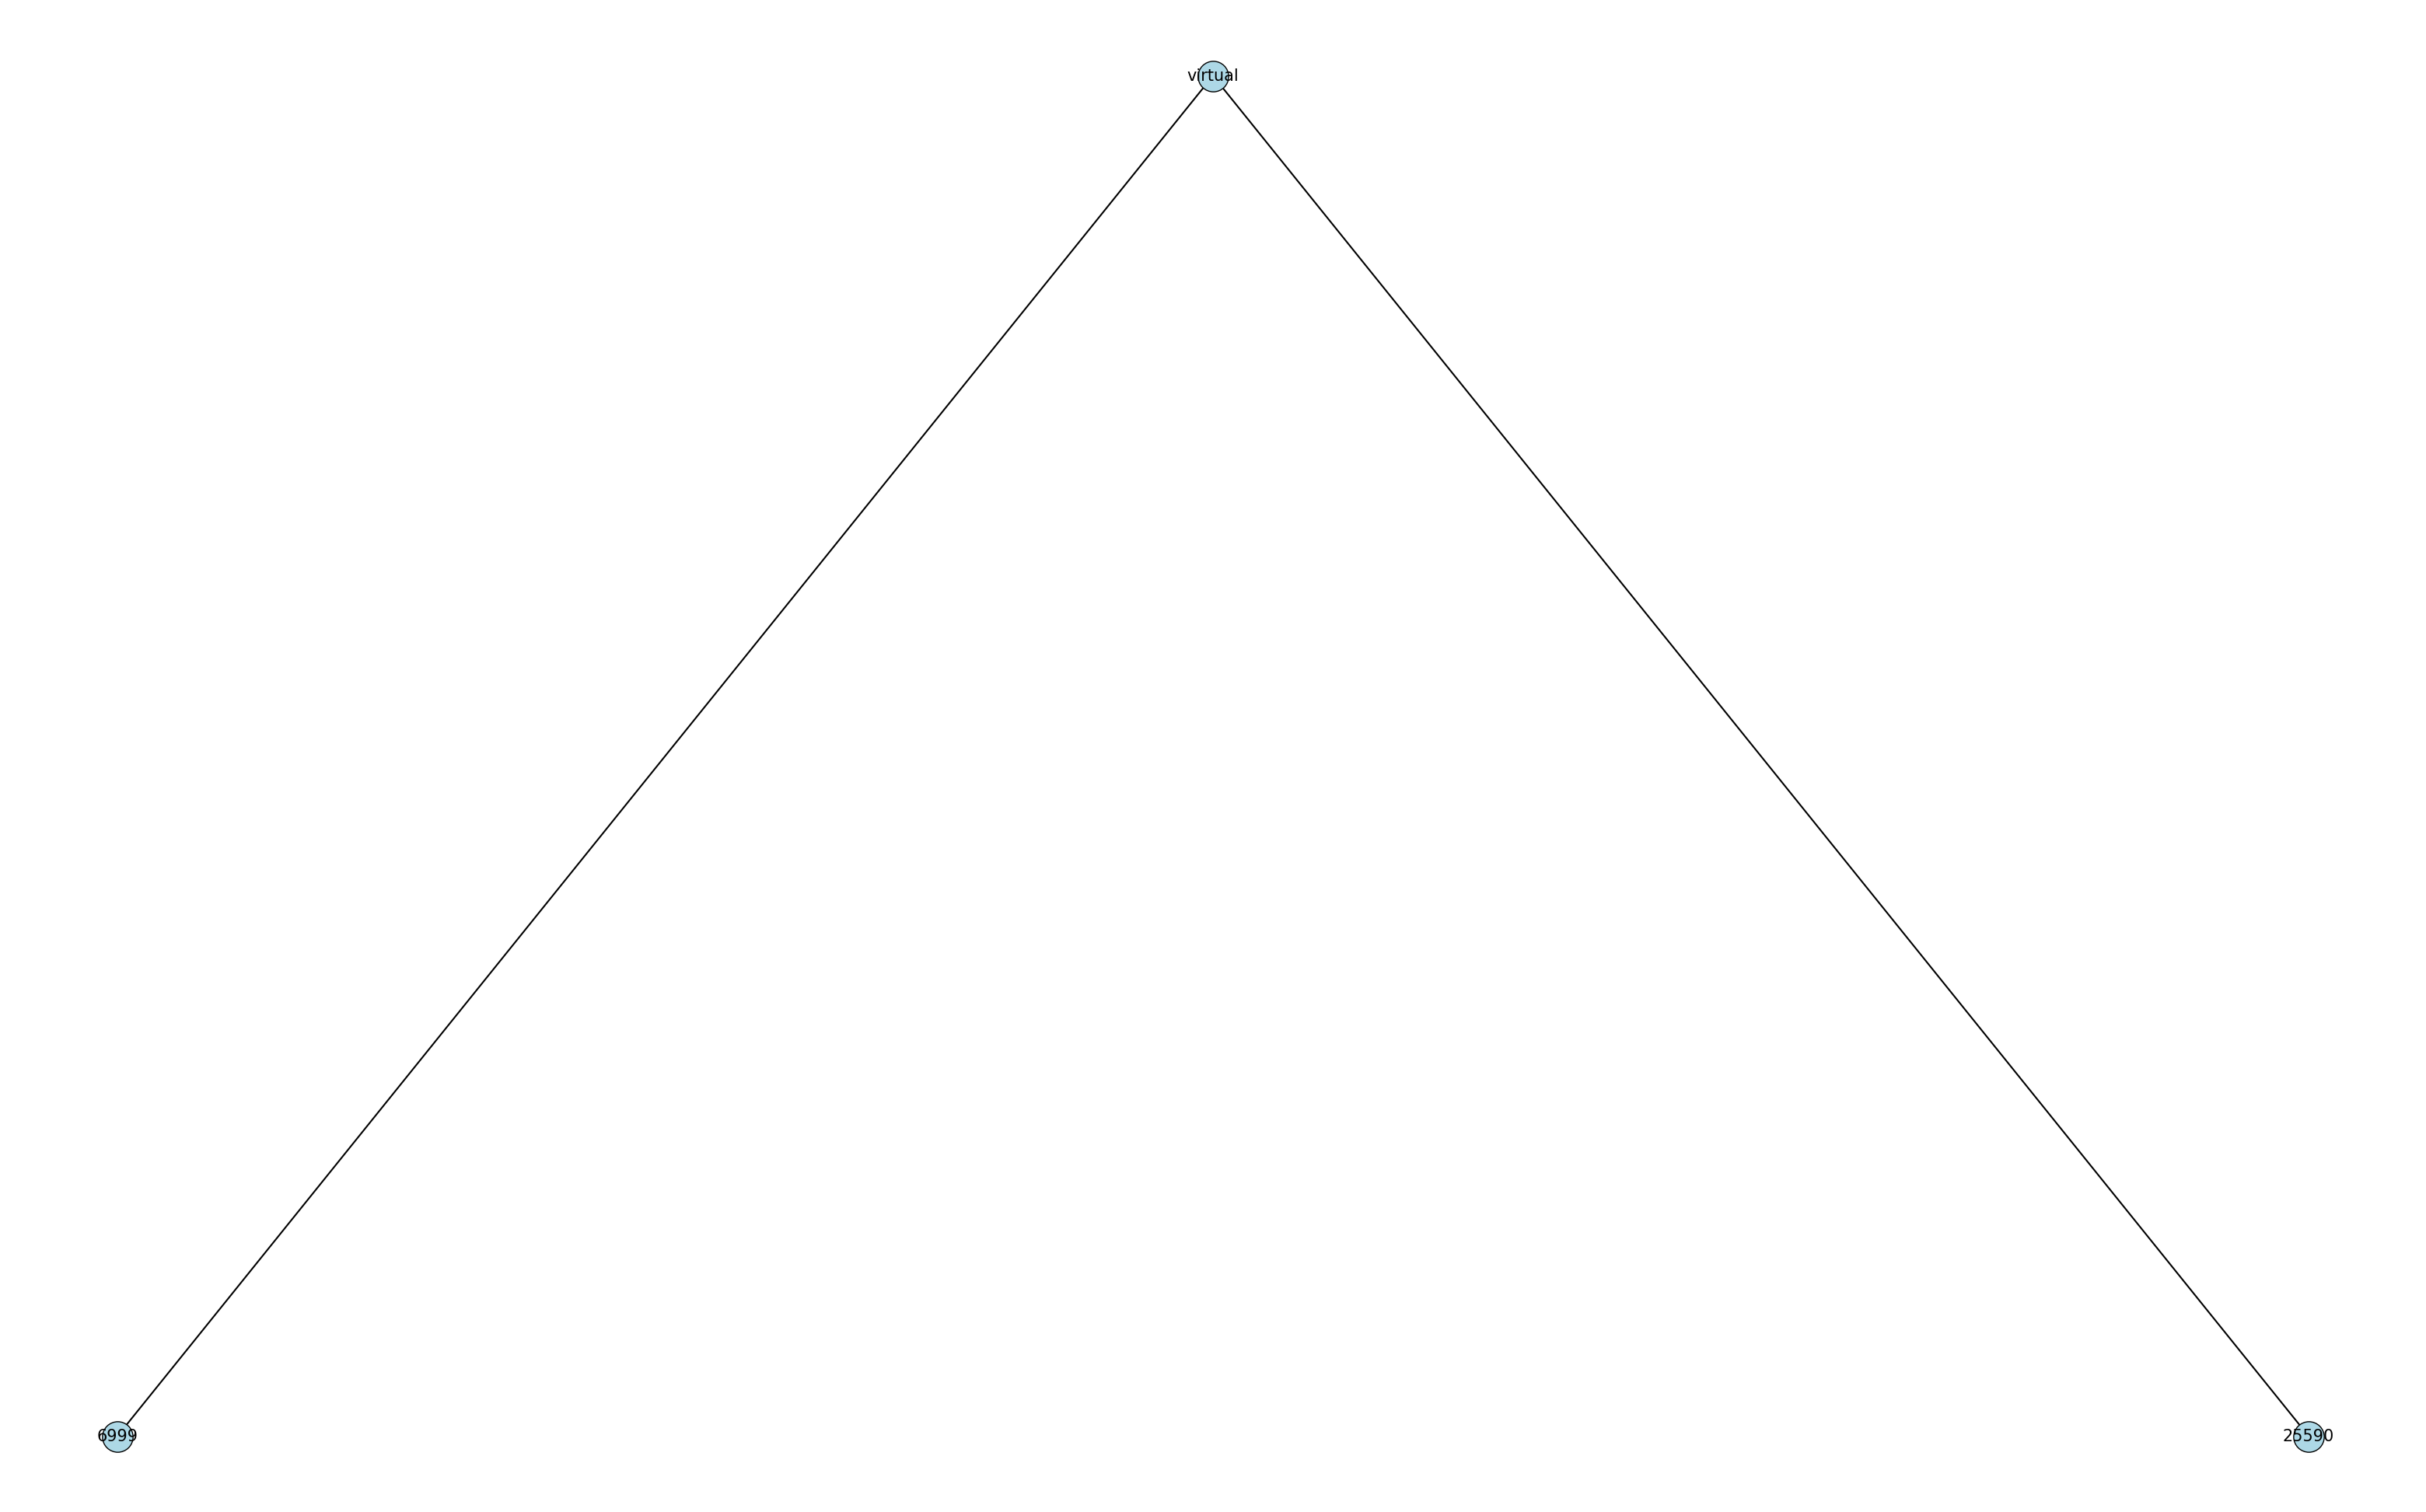

In [20]:
plotting_ftcs_tree.plot_tree(pruned_tree.hierarchy.root,pruned_tree)

In [21]:
# Create a directory to save the plots
output_dir = "TreeNode_XY_Plots"
os.makedirs(output_dir, exist_ok=True)

# Define colors for each true label
cols = {-1: 'lightgray', 0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'purple', 5: 'yellow', 6: 'magenta'}


alphas = {-1: 0.2, 0: 0.9, 1: 0.9, 2: 0.9, 3: 0.9, 4: 0.9, 5: 0.9, 6: 0.9}
zorders = {0: 0, 1: 1, 2: 1, 3: 1}

# Generate plots for each tree node
for node in tree_sigma.hierarchy.traverse_top_down():
    plotting_ftcs_tree.plot_node_data(node, df, labels, output_dir, cols, alphas, zorders)

# Apply square grid in Tree leaf nodes

In [23]:
# make a leaf node dataframe
df_leaves = tree_related_ftcs.extract_leaf_nodes(pruned_tree, df)

6999_0
1
25590_0
2


In [24]:
# initialize parameters for grid 
grid_size = 20
shift_vector = [3, 3, 3]
num_rotations = 3
rotation_axis = 'z'
rotation_angle = 30
num_shifts = 2
projection = 'xz'
K = 9
solver = 'nmf'
consensus_nclass = 6
random_state = 42
max_iter = 1000
method = 'random'
theta=0.01
epsilon=0.001

# apply square grid to every leaf node 
# Get the subset for this cluster
df_cluster = df_leaves[df_leaves['cluster'] == '6999_0'].copy()

# Now labels are already in df_cluster
labels_cluster = df_cluster['labels'].values

# Remove background
#  df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(
#      df_cluster, labels_cluster, ['x', 'y', 'z', 'vt_ra', 'vt_dec'], print_info=True)

#  df_filtered = df_filtered.reset_index(drop=True)
# labels_filtered = pd.Series(labels_filtered).reset_index(drop=True).values

# Reset index to prevent mismatch
df_cluster['original_index'] = df_cluster.index
df_cluster = df_cluster.reset_index(drop=True)
labels_cluster = pd.Series(labels_cluster).reset_index(drop=True).values


# square grid consensus clustering (chose if from all data of leaf node or from filtered)
consensus_results = square_grid.run_square_grid_consensus_clustering(df_cluster, grid_size, shift_vector, K, labels_cluster, solver,
                                     consensus_nclass, random_state, colors, alphas, zorders, num_rotations,
                                     rotation_axis, rotation_angle, num_shifts, projection,
                                     max_iter, method, theta, epsilon, initial_partition=None,
                                     rho_multiplier=None, verbose=False, th_dist=2,
                                     dist_max=1e3, print_info = False, entire_G=False)

nmi = consensus_clusterings.calculate_nmi(consensus_results, labels_cluster, background_label=0)
print(nmi)
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_results, labels_cluster, background_label=0)
print(overall_nmi)

0.34888511325139276
Overall NMI (ignoring background points): 0.3489

Cluster 0:
  - Number of points: 4126
  - Purity (excluding background): 0.4390
  - True label distribution in this cluster:
    * Background noise: 4085 points
    * True label 1: 17 points
    * True label 5: 18 points
    * True label 7: 6 points


Cluster 1: Only background points present.
  - Number of points: 9192

Cluster 2:
  - Number of points: 5887
  - Purity (excluding background): 0.9200
  - True label distribution in this cluster:
    * Background noise: 5862 points
    * True label 1: 23 points
    * True label 3: 2 points


Cluster 3:
  - Number of points: 4065
  - Purity (excluding background): 0.5375
  - True label distribution in this cluster:
    * Background noise: 3985 points
    * True label 1: 43 points
    * True label 3: 6 points
    * True label 5: 31 points


Cluster 4:
  - Number of points: 1810
  - Purity (excluding background): 0.9902
  - True label distribution in this cluster:
    * Ba

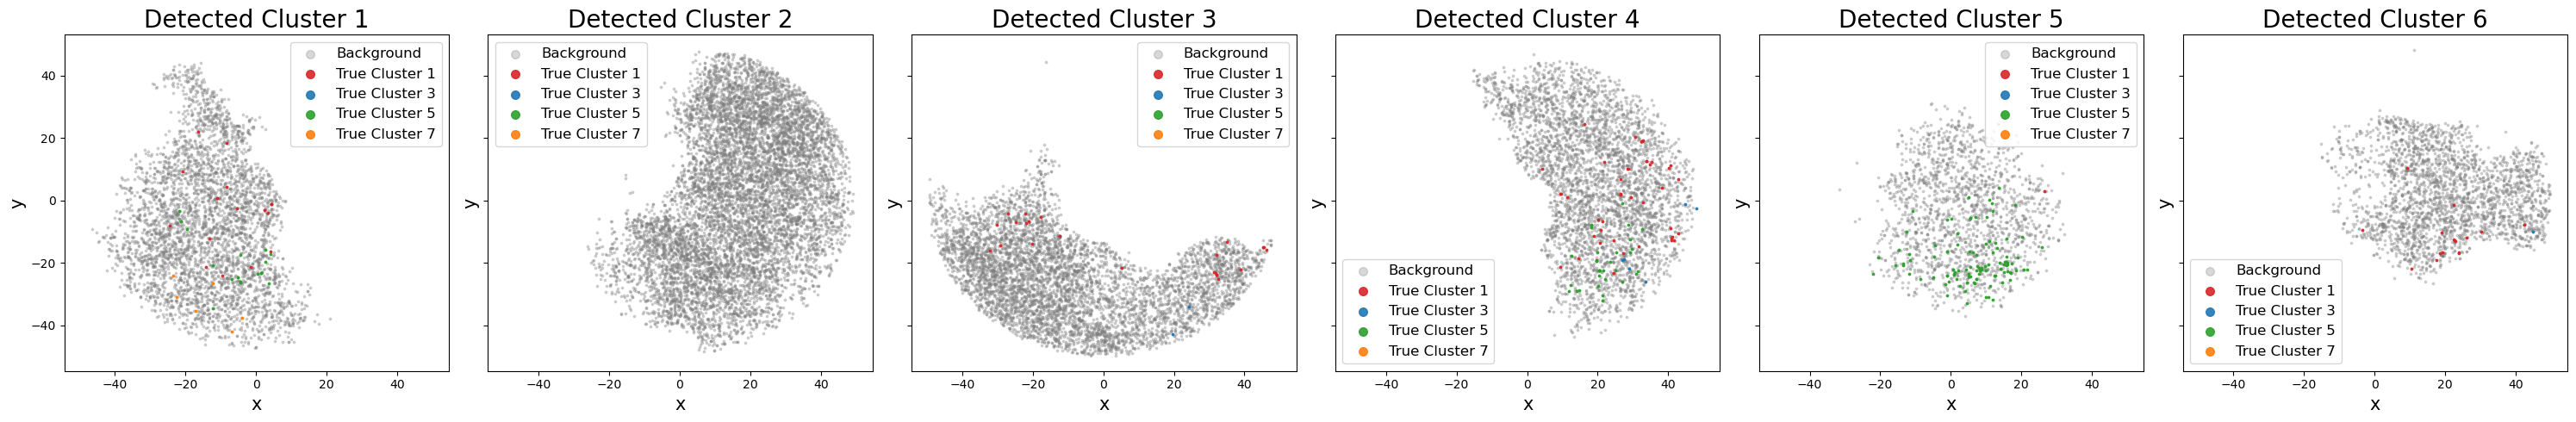

In [25]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]

visualisations.visualise_cluster_result(
    df=df_cluster,
    cluster_labels=consensus_results,
    true_labels=labels_cluster,
    K=len(np.unique(consensus_results)),  
    x_col='x',
    y_col='y',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [34]:
# initialize parameters for grid 
grid_size = 20
shift_vector = [3, 3, 3]
num_rotations = 3
rotation_axis = 'z'
rotation_angle = 30
num_shifts = 2
projection = 'xz'
K = 9
solver = 'nmf'
consensus_nclass = 6
random_state = 42
max_iter = 1000
method = 'random'
theta=0.01
epsilon=0.001

# apply square grid to every leaf node 
# Get the subset for this cluster
df_cluster = df_leaves[df_leaves['cluster'] == '25590_0'].copy()

# Now labels are already in df_cluster
labels_cluster = df_cluster['labels'].values

# Remove background
#  df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(
#      df_cluster, labels_cluster, ['x', 'y', 'z', 'vt_ra', 'vt_dec'], print_info=True)

#  df_filtered = df_filtered.reset_index(drop=True)
# labels_filtered = pd.Series(labels_filtered).reset_index(drop=True).values

# Reset index to prevent mismatch
df_cluster['original_index'] = df_cluster.index
df_cluster = df_cluster.reset_index(drop=True)
labels_cluster = pd.Series(labels_cluster).reset_index(drop=True).values


# square grid consensus clustering (chose if from all data of leaf node or from filtered)
consensus_results = square_grid.run_square_grid_consensus_clustering(df_cluster, grid_size, shift_vector, K, labels_cluster, solver,
                                     consensus_nclass, random_state, colors, alphas, zorders, num_rotations,
                                     rotation_axis, rotation_angle, num_shifts, projection,
                                     max_iter, method, theta, epsilon, initial_partition=None,
                                     rho_multiplier=None, verbose=False, th_dist=2,
                                     dist_max=1e3, print_info = False, entire_G=False)

nmi = consensus_clusterings.calculate_nmi(consensus_results, labels_cluster, background_label=0)
print(nmi)
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_results, labels_cluster, background_label=0)
print(overall_nmi)

0.0
Overall NMI (ignoring background points): 0.0000

Cluster 0:
  - Number of points: 375
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 374 points
    * True label 1: 1 points


Cluster 1:
  - Number of points: 944
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 935 points
    * True label 1: 9 points


Cluster 2:
  - Number of points: 342
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 340 points
    * True label 1: 2 points


Cluster 3: Only background points present.
  - Number of points: 198

Cluster 4:
  - Number of points: 8022
  - Purity (excluding background): 1.0000
  - True label distribution in this cluster:
    * Background noise: 8019 points
    * True label 1: 3 points


Cluster 5: Only background points present.
  - Number of points: 252

0.0


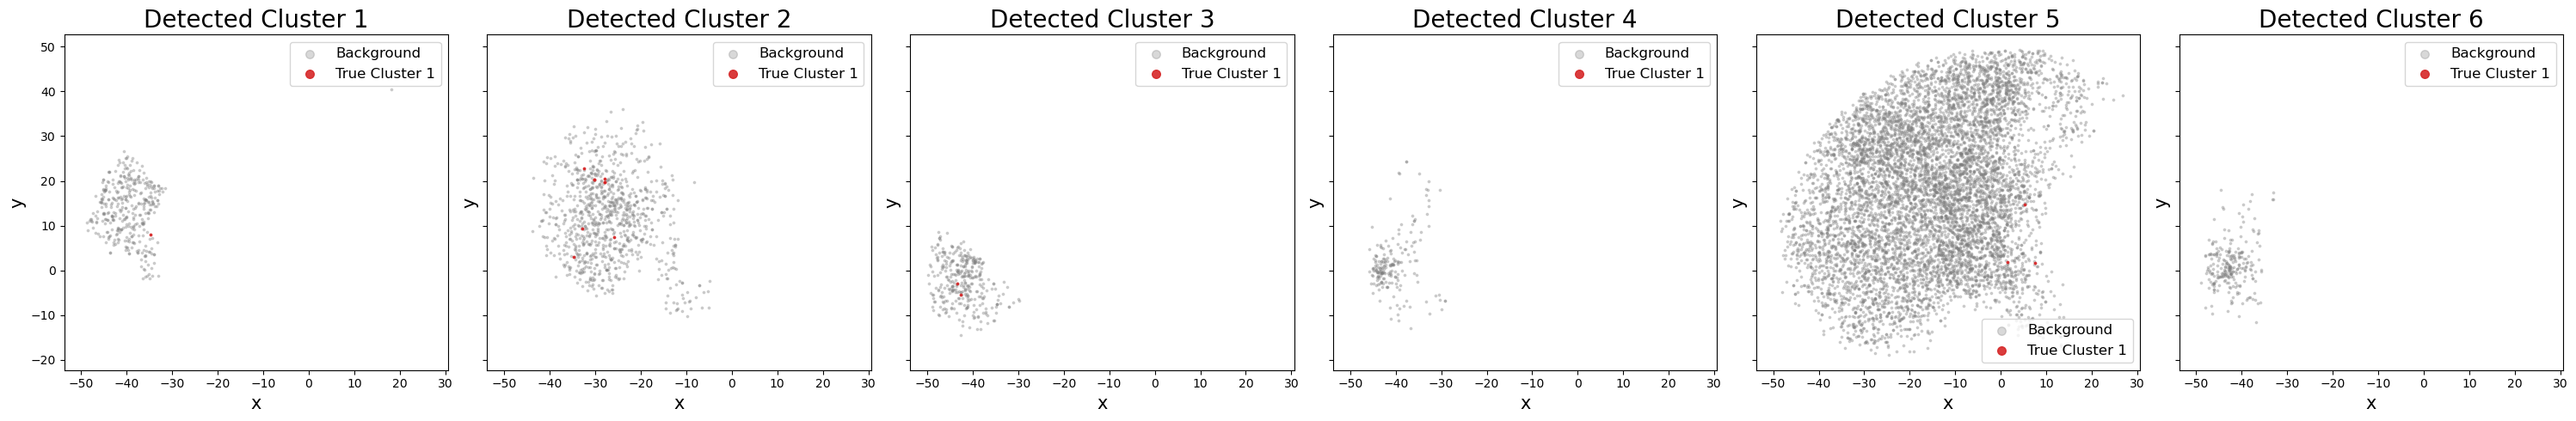

In [36]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]

visualisations.visualise_cluster_result(
    df=df_cluster,
    cluster_labels=consensus_results,
    true_labels=labels_cluster,
    K=len(np.unique(consensus_results)),  
    x_col='x',
    y_col='y',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [30]:
# initialize parameters for grid 
grid_size = 20
shift_vector = [3, 3, 3]
num_rotations = 3
rotation_axis = 'z'
rotation_angle = 30
num_shifts = 2
projection = 'xz'
K = 9
solver = 'nmf'
consensus_nclass = 6
random_state = 42
max_iter = 1000
method = 'random'
theta=0.01
epsilon=0.001

# apply square grid to every leaf node 
for cluster_id in df_leaves['cluster'].unique():
    # Get the subset for this cluster
    df_cluster = df_leaves[df_leaves['cluster'] == cluster_id].copy()
    
    # Now labels are already in df_cluster
    labels_cluster = df_cluster['labels'].values

    # Remove background
  #  df_filtered, labels_filtered, _ = shell_grid.remove_background_noise(
  #      df_cluster, labels_cluster, ['x', 'y', 'z', 'vt_ra', 'vt_dec'], print_info=True)
  
  #  df_filtered = df_filtered.reset_index(drop=True)
   # labels_filtered = pd.Series(labels_filtered).reset_index(drop=True).values

    # Reset index to prevent mismatch
    df_cluster['original_index'] = df_cluster.index
    df_cluster = df_cluster.reset_index(drop=True)
    labels_cluster = pd.Series(labels_cluster).reset_index(drop=True).values


    # square grid consensus clustering (chose if from all data of leaf node or from filtered)
    consensus_results = square_grid.run_square_grid_consensus_clustering(df_cluster, grid_size, shift_vector, K, labels_cluster, solver,
                                         consensus_nclass, random_state, colors, alphas, zorders, num_rotations,
                                         rotation_axis, rotation_angle, num_shifts, projection,
                                         max_iter, method, theta, epsilon, initial_partition=None,
                                         rho_multiplier=None, verbose=False, th_dist=2,
                                         dist_max=1e3, print_info = False, entire_G=True)
    
    nmi = consensus_clusterings.calculate_nmi(consensus_results, labels_cluster, background_label=0)
    print(nmi)
    overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_results, labels_cluster, background_label=0)
    print(overall_nmi)

KeyboardInterrupt: 

In [67]:
df_cluster

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,...,y,z,vx,vy,vz,dist,vt_ra,vt_dec,labels,cluster
0,1636148068921376768,Gaia DR3 5937154643067504512,5937154643067504512,1007516695,2016.0,250.637694,0.014857,-51.835705,0.011336,25.893203,...,-16.576256,-2.521384,NaN,NaN,NaN,38.620174,-10701.743648,-78826.233926,0,6999_0
5,1636148068921376768,Gaia DR3 5912721020734479104,5912721020734479104,949574069,2016.0,264.671999,0.013376,-59.707844,0.012540,39.216169,...,-11.340448,-6.466879,-19.872143,-10.100755,-24.873955,25.499686,15117.562639,-29113.096888,0,6999_0
13,1636148068921376768,Gaia DR3 5912921509809469952,5912921509809469952,286300768,2016.0,264.635582,0.023203,-58.544378,0.019932,61.152174,...,-7.034953,-3.985679,-12.773094,-17.974233,-13.576938,16.352648,1542.085388,-25846.536297,0,6999_0
37,1636148068921376768,Gaia DR3 5912492318012378752,5912492318012378752,1541123826,2016.0,261.777913,0.019544,-60.269124,0.016679,44.918622,...,-10.360089,-5.280688,-2.947788,-12.256630,3.162998,22.262481,-9607.351803,-8404.339396,1,6999_0
41,1636148068921376768,Gaia DR3 5912380962403300096,5912380962403300096,851998223,2016.0,263.521562,0.014292,-59.777571,0.011952,26.695519,...,-16.895497,-9.202329,-58.815576,-43.677125,-21.724190,37.459470,-7980.655373,-71606.903685,0,6999_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37869,1636148068921376768,Gaia DR3 1793931771375192448,1793931771375192448,685452876,2016.0,323.648130,0.031699,22.037134,0.026412,20.899429,...,42.755095,-17.600374,-30.612976,-12.592597,0.664783,47.848197,22903.844266,13999.986230,0,6999_0
37870,1636148068921376768,Gaia DR3 1793946026371051648,1793946026371051648,369031821,2016.0,324.150050,0.026699,22.075936,0.026925,20.151555,...,44.329253,-18.502447,NaN,NaN,NaN,49.623962,-23017.339322,369.228335,0,6999_0
37871,1636148068921376768,Gaia DR3 6029992663310612096,6029992663310612096,1354746818,2016.0,256.116435,0.022222,-28.583872,0.011692,54.725979,...,-1.503843,2.439620,15.335727,-15.676930,-17.630386,18.272857,7215.704978,-23265.553814,0,6999_0
37874,1636148068921376768,Gaia DR3 6029956340657655424,6029956340657655424,508106269,2016.0,256.662889,0.019832,-28.618132,0.012412,23.650881,...,-3.293073,5.348067,-24.271973,-17.914320,2.711918,42.281722,-16209.613196,-12604.183803,0,6999_0


# overall_nmi = consensus_clusterings.calculate_nmi_and_purity(consensus_results, labels, background_label=0)

In [ ]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=consensus_results,
    true_labels=labels,
    K=len(np.unique(consensus_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [ ]:
print(np.unique(consensus_results, return_counts=True))

In [ ]:
# Rerun square grid and consensus clustering on specific detected cluster after previous run of the algorithm 
detected_cluster_id = 5
K = 6

clustering_results, subset_df, subset_true_labels, clustering_time = square_grid.rerun_square_grid_clustering_on_detected_cluster(
    df, labels, detected_cluster_id, consensus_results, 
    K, solver, consensus_nclass, num_rotations, shift_vector, num_shifts, 
    grid_size, projection='xy', colors=colors, alphas=alphas, zorders=zorders,
    rotation_axis='z', rotation_angle=30, max_iter=1000, method="random", 
    theta=0.01, epsilon=0.001, th_dist=2, dist_max=1000, 
    print_info=False, entire_G=False)

In [ ]:
overall_nmi = consensus_clusterings.calculate_nmi_and_purity(clustering_results, subset_true_labels, background_label=0)

In [ ]:
visualisations.visualise_cluster_result(
    df=subset_df,
    cluster_labels=clustering_results,
    true_labels=subset_true_labels,
    K=len(np.unique(clustering_results)),  
    x_col='vt_ra',
    y_col='vt_dec',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)

In [ ]:
# Try different parameters combinations, save result to csv file; for filtered data from background points
grid_sizes = [10]
shift_vectors = [[3, 3, 3]]
K_values = [9]
solvers = ['cspa', 'hgpa', 'mcla', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
num_rotations_values = [3]
rotation_angles = [30]
num_shifts_values = [3]
max_iter_values = [1000]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [5, 10, 25, None]
dist_max_values = [1000]

In [ ]:
#results_filtereddf = square_grid.test_square_grid_clustering(df_filtered, labels_filtered, grid_sizes, shift_vectors, K_values, solvers, 
#                                consensus_nclass_values, num_rotations_values, rotation_angles, 
   #                             num_shifts_values, max_iter_values, theta_values, epsilon_values, 
      #                          th_dist_values, dist_max_values, colors, alphas, zorders, output_csv="clustering_results_filtered_squaregrid.csv")

In [ ]:
#best_options_filtered, worst_options_filtered = shell_grid.get_best_and_worst_options("clustering_results_filtered_squaregrid.csv", top_n=10)

In [ ]:
#print("Top 10 best configurations:")
#best_options_filtered

In [ ]:
#print("\nTop 10 worst configurations:")
#worst_options_filtered

In [ ]:
# Try different parameters combinations, save result to csv file; for unfiltered data from background points
grid_sizes = [10]
shift_vectors = [[3, 3, 3]]
K_values = [9]
solvers = ['cspa', 'hbgf', 'nmf']
consensus_nclass_values = [9, 6]
num_rotations_values = [3]
rotation_angles = [30]
num_shifts_values = [3]
max_iter_values = [1000]
theta_values = [0.01]
epsilon_values = [0.001]
th_dist_values = [5, 10, 25, None]
dist_max_values = [1000]

In [ ]:
#results_nonfiltereddf2 = square_grid.test_square_grid_clustering(df, labels, grid_sizes, shift_vectors, K_values, solvers, 
  #                              consensus_nclass_values, num_rotations_values, rotation_angles, 
  #                              num_shifts_values, max_iter_values, theta_values, epsilon_values, 
    #                            th_dist_values, dist_max_values, colors, alphas, zorders, output_csv="clustering_results_nonfiltered_squaregrid2.csv")

In [ ]:
#best_options_nonfiltered, worst_options_nonfiltered = shell_grid.get_best_and_worst_options("clustering_results_nonfiltered_squaregrid2.csv", top_n=10)


In [ ]:
#print("Top 10 best configurations:")
#best_options_nonfiltered

In [ ]:
#print("\nTop 10 worst configurations:")
#worst_options_nonfiltered